<a href="https://colab.research.google.com/github/ajs-sw/2026_tues_bigdatacomputing_class/blob/main/20230579_%EC%95%88%EC%A0%95%EC%88%98_%EC%A4%91%EA%B0%84%EA%B3%A0%EC%82%AC_%ED%94%84%EB%A1%9C%EA%B7%B8%EB%9E%98%EB%B0%8D_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [중간고사 실기 과제] 시계열 기상 데이터 통합 분석 파이프라인 구축
1. 과제 개요

  - 본 과제는 실무 데이터 분석 프로세스를 경험하기 위해 웹상의 기상 데이터를 수집하고, 이를 기계학습 모델링이 가능한 형태의 '깨끗한 데이터'로 가공하는 통합 분석 파이프라인을 개별 함수 단위로 구현하기.

2. 데이터 소스

  - URL: https://github.com/dongupak/DataML/raw/main/csv/weather.csv

  - 주요 컬럼: 지점, 일시, 평균기온, 최대풍속, 평균풍속

3. 핵심 요구 사항 (평가 기준)

  - 모듈화 설계:
    - 모든 기능은 독립적인 함수로 작성되어야 하고,
    - main() 함수에서 제어되어야 함.

  - 데이터 정규화 (Min-Max Scaling):
    - 특정 수치 데이터를 0과 1 사이로 변환하는 함수를 포함해야 함.

  - 시계열 핸들링:
    - 날짜 변환, 인덱스 설정 및 7일 이동 평균 추세선을 생성해야 함.

  - 데이터 재구조화:
    - pivot_table과 groupby를 활용하여 다차원적인 통계량을 산출해야 함.

  - 엑셀 내보내기 (To Excel):
    - 분석 결과인 전처리 데이터, 계절별 통계, 연도별 피벗 테이블을 하나의 엑셀 파일(weather_analysis_report.xlsx)의 별도 시트에 각각 저장해야 함.

  - 다음과 같은 데이터분석 그래프을 생성해야 함.
  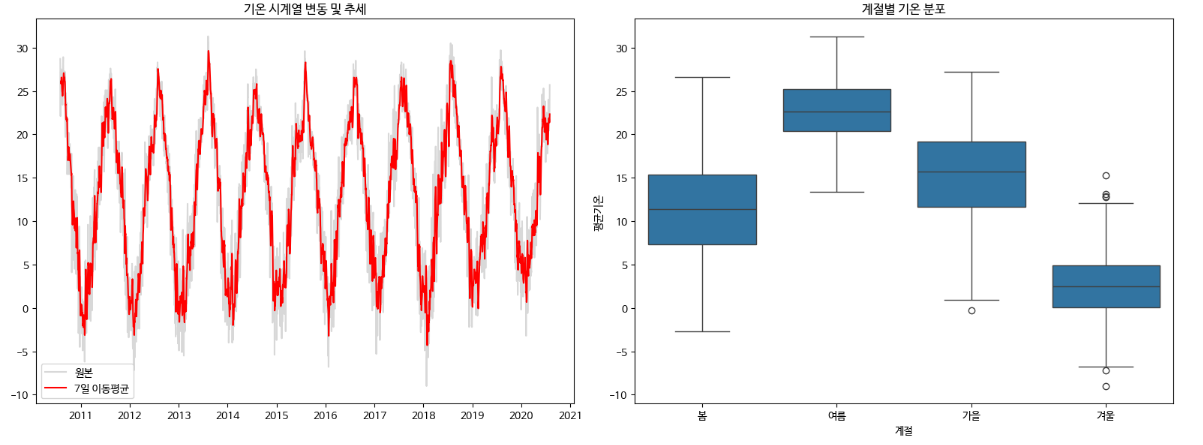

  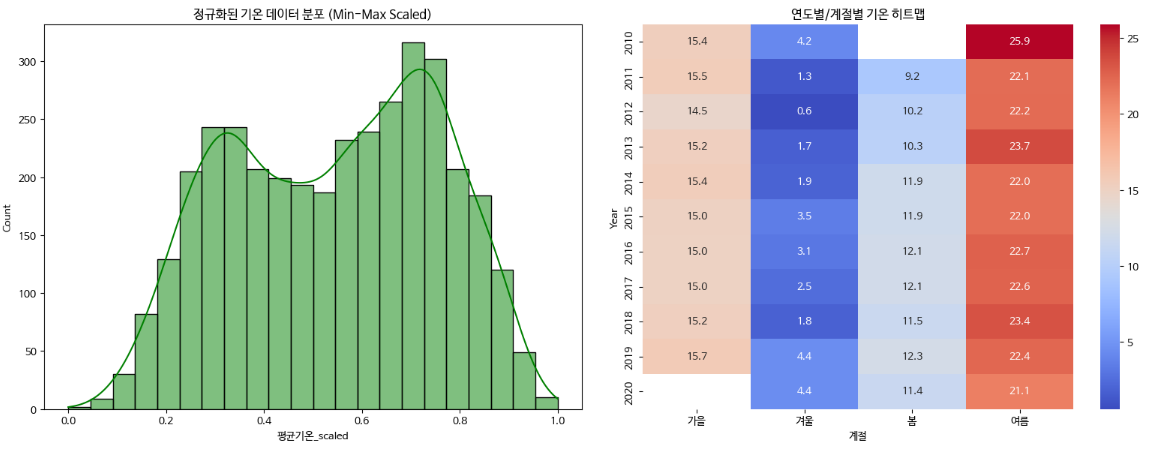



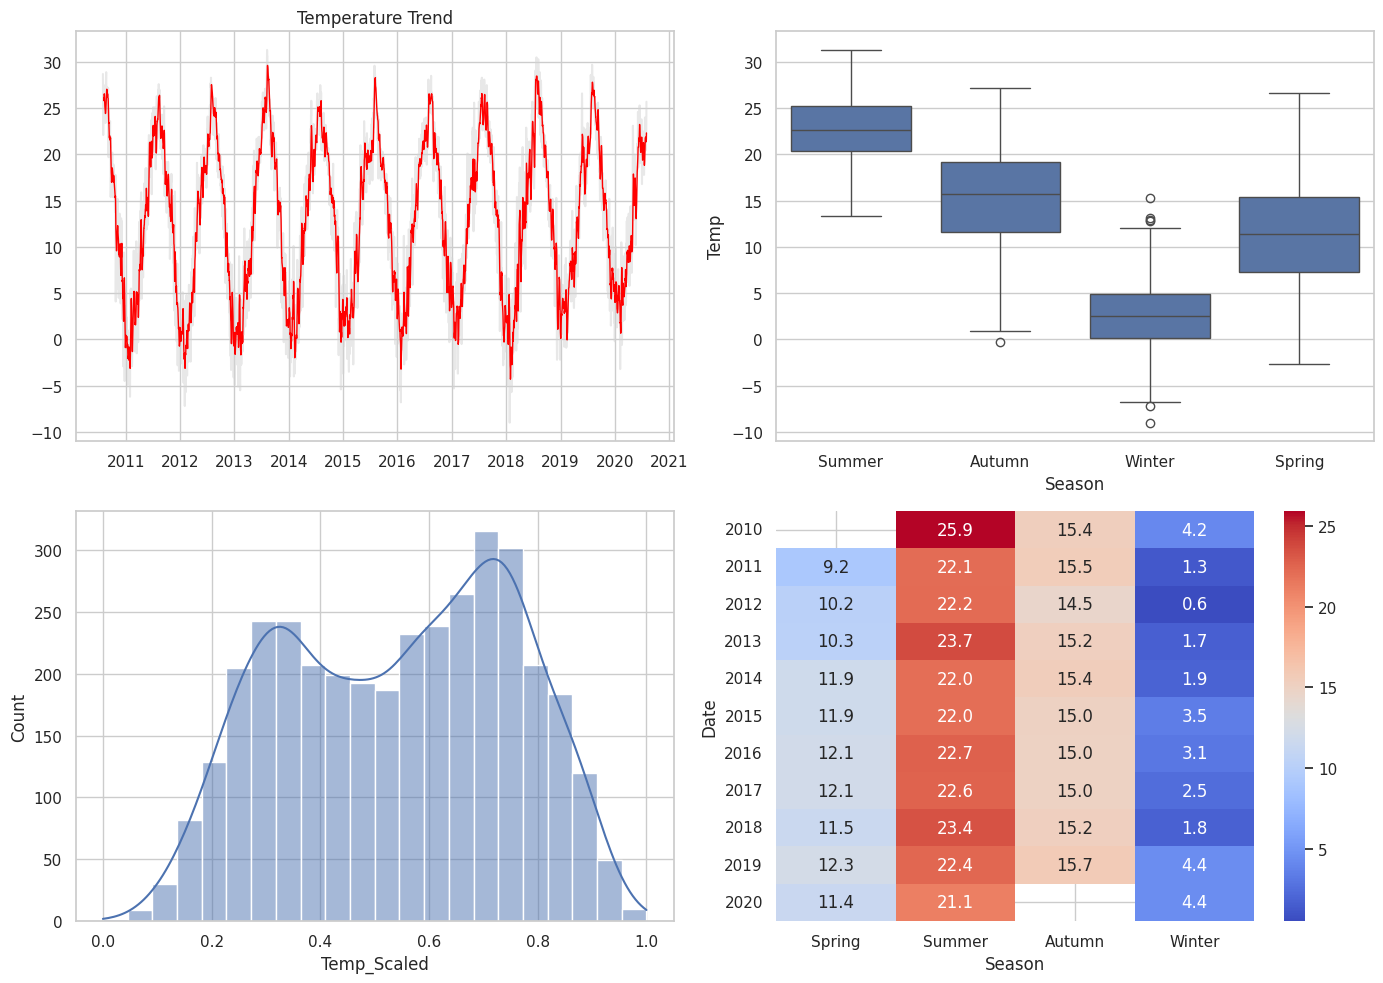

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

def prepare_data(url):
    df = pd.read_csv(url, encoding='cp949')

    cols = {'일시': 'Date', '평균기온': 'Temp'}
    df.rename(columns=cols, inplace=True)

    df['Date'] = pd.to_datetime(df['Date'])
    df.dropna(subset=['Temp'], inplace=True)

    df['Season'] = df['Date'].dt.month.map({
        3:'Spring', 4:'Spring', 5:'Spring',
        6:'Summer', 7:'Summer', 8:'Summer',
        9:'Autumn', 10:'Autumn', 11:'Autumn',
        12:'Winter', 1:'Winter', 2:'Winter'
    })

    df['MA7'] = df['Temp'].rolling(7).mean()
    df['Temp_Scaled'] = MinMaxScaler().fit_transform(df[['Temp']])

    return df

def run_analysis(df):
    stats = df.groupby('Season')['Temp'].describe()
    pivot = df.pivot_table('Temp', index=df['Date'].dt.year, columns='Season')
    order = [s for s in ['Spring', 'Summer', 'Autumn', 'Winter'] if s in pivot.columns]

    return stats, pivot[order]

def plot_results(df, pivot):
    sns.set_style("whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes[0,0].plot(df['Date'], df['Temp'], color='lightgray', alpha=0.5)
    axes[0,0].plot(df['Date'], df['MA7'], color='red', lw=1)
    axes[0,0].set_title("Temperature Trend")

    sns.boxplot(data=df, x='Season', y='Temp', ax=axes[0,1])

    sns.histplot(df['Temp_Scaled'], kde=True, ax=axes[1,0])

    sns.heatmap(pivot, annot=True, fmt=".1f", cmap="coolwarm", ax=axes[1,1])

    plt.tight_layout()
    plt.show()

def main():
    path = "https://github.com/dongupak/DataML/raw/main/csv/weather.csv"

    data = prepare_data(path)
    s_stats, p_table = run_analysis(data)

    plot_results(data, p_table)

    with pd.ExcelWriter("weather_analysis_report.xlsx") as writer:
        data.to_excel(writer, sheet_name='Data', index=False)
        s_stats.to_excel(writer, sheet_name='Statistics')
        p_table.to_excel(writer, sheet_name='Yearly_Pivot')

if __name__ == "__main__":
    main()